<a href="https://colab.research.google.com/github/surjisudha/Game-Analytics-PowerBI/blob/main/Game_Analytics_%26_Sales_Intelligence_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

games = pd.read_csv("games.csv")
sales = pd.read_csv("vgsales.csv")

print("Games:", games.shape)
print("Sales:", sales.shape)

Checking columns and data types

In [ ]:
print("GAMES DATASET")
print(games.info())

print("\n" + "="*50)

print("SALES DATASET")
print(sales.info())

Checking missing values

In [ ]:
print("Missing values in games.csv:")
print(games.isnull().sum())

print("\nMissing values in vgsales.csv:")
print(sales.isnull().sum())

Checking duplicates

In [ ]:
print("Duplicate rows in games.csv:", games.duplicated().sum())
print("Duplicate rows in vgsales.csv:", sales.duplicated().sum())

Remove unnecessary column

In [ ]:
games = games.drop("Unnamed: 0", axis=1)

print(games.columns)

Handle missing values

In [ ]:
games["Team"] = games["Team"].fillna("Unknown")
games["Rating"] = games["Rating"].fillna(games["Rating"].median())
games["Summary"] = games["Summary"].fillna("No Summary")

sales["Publisher"] = sales["Publisher"].fillna("Unknown")
sales["Year"] = sales["Year"].fillna(0)

print("Missing values handled successfully!")

Check that missing values are handled

In [ ]:
print("Games missing values:")
print(games.isnull().sum())

print("\nSales missing values:")
print(sales.isnull().sum())

Convert engagement columns (k to num)

In [ ]:
def convert_to_number(value):
    value = str(value).strip()

    if value.endswith("K"):
        return float(value[:-1]) * 1000

    elif value.endswith("M"):
        return float(value[:-1]) * 1000000

    else:
        return float(value)


columns = [
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

for column in columns:
    games[column] = games[column].apply(convert_to_number)

print(games[columns].head())

Verifying the data types

In [ ]:
print(games[columns].dtypes)

Now we'll convert Release Date from text to an actual date and create a new Release Year column.

In [ ]:
games["Release Date"] = pd.to_datetime(
    games["Release Date"],
    errors="coerce"
)

games["Release Year"] = games["Release Date"].dt.year

print(games[["Title", "Release Date", "Release Year"]].head())

In [ ]:
print(games["Release Date"].dtype)
print("\nMissing Release Dates:", games["Release Date"].isnull().sum())

Handling the 3 missing release dates

In [ ]:
games["Release Year"] = games["Release Year"].fillna(0).astype(int)

print("Missing Release Dates:", games["Release Date"].isnull().sum())
print("Missing Release Years:", games["Release Year"].isnull().sum())

print(games[["Title", "Release Date", "Release Year"]].head())

Clean the Sales Dataset

In [ ]:
print(sales[["Year", "Publisher", "Genre", "Platform"]].head(10))

In [ ]:
print("Unique Platforms:", sales["Platform"].nunique())
print("Unique Genres:", sales["Genre"].nunique())
print("Unique Publishers:", sales["Publisher"].nunique())

In [ ]:
print(sales.describe())

Fix the Year column

In [ ]:
sales["Year"] = sales["Year"].replace(0, pd.NA)

print("Missing Years:", sales["Year"].isna().sum())
print(sales["Year"].describe())

Clean text columns

Now let's standardize the three important categorical columns:

Platform, Genre, Publisher

In [ ]:
# Remove extra spaces
sales["Name"] = sales["Name"].str.strip()
sales["Platform"] = sales["Platform"].str.strip()
sales["Genre"] = sales["Genre"].str.strip()
sales["Publisher"] = sales["Publisher"].str.strip()

# Replace empty strings with Unknown
sales["Name"] = sales["Name"].replace("", "Unknown")
sales["Platform"] = sales["Platform"].replace("", "Unknown")
sales["Genre"] = sales["Genre"].replace("", "Unknown")
sales["Publisher"] = sales["Publisher"].replace("", "Unknown")

# Check unique values
print("Platforms:", sales["Platform"].nunique())
print("Genres:", sales["Genre"].nunique())
print("Publishers:", sales["Publisher"].nunique())

In [ ]:
print("\nPlatforms:")
print(sorted(sales["Platform"].unique()))

print("\nGenres:")
print(sorted(sales["Genre"].unique())[:30])

 Final validation

In [ ]:
print("GAMES DATASET")
print(games.info())

print("\n" + "="*60)

print("SALES DATASET")
print(sales.info())

In [ ]:
print("\nGames missing values:")
print(games.isnull().sum())

print("\nSales missing values:")
print(sales.isnull().sum())

In [ ]:
games.to_csv("clean_games.csv", index=False)
sales.to_csv("clean_vgsales.csv", index=False)

print("\n✅ Cleaned datasets saved successfully!")
print("1. clean_games.csv")
print("2. clean_vgsales.csv")

Now we'll use Python to explore the cleaned data and generate actual insights.

EDA— Basic Statistics & Distribution.
Basic statistics

In [ ]:
print("GAMES DATASET")
print(games.describe())

print("\n" + "="*60)

print("SALES DATASET")
print(sales.describe())

In [ ]:
print("Games:", len(games))
print("Unique game titles:", games["Title"].nunique())
print("Unique developers:", games["Team"].nunique())
print("Unique genres:", games["Genres"].nunique())

print("\nSales:", len(sales))
print("Unique games:", sales["Name"].nunique())
print("Unique platforms:", sales["Platform"].nunique())
print("Unique genres:", sales["Genre"].nunique())
print("Unique publishers:", sales["Publisher"].nunique())

In [ ]:
print("Top 10 Most Wishlisted Games")
print(
    games[["Title", "Wishlist"]]
    .sort_values("Wishlist", ascending=False)
    .head(10)
)

let's create an EDA-safe copy of the games data.

In [ ]:
games_eda = games.copy()

# Treat unknown release year as missing
games_eda["Release Year"] = games_eda["Release Year"].replace(0, pd.NA)

print("EDA dataset shape:", games_eda.shape)
print("Unknown release years:", games_eda["Release Year"].isna().sum())

Remove duplicate game titles for title-level analysis
We won't delete these records from the original dataset.
Instead, we'll create a separate title-level dataset:

In [ ]:
games_unique = games_eda.drop_duplicates(subset="Title").copy()

print("Original rows:", len(games_eda))
print("Unique game titles:", len(games_unique))

Correct Top 10 Wishlisted Games

In [ ]:
top_wishlist = (
    games_unique[["Title", "Wishlist"]]
    .sort_values("Wishlist", ascending=False)
    .head(10)
)

print(top_wishlist.to_string(index=False))

EDA Questions:
Q1 : What are the top-rated games by user reviews?

In [ ]:
top_rated = (
    games_unique[["Title", "Rating"]]
    .sort_values("Rating", ascending=False)
    .head(10)
)

print(top_rated.to_string(index=False))

Q2. Which developers (Teams) have the highest average ratings?

In [ ]:
top_developers = (
    games.groupby("Team")["Rating"]
    .agg(["mean", "count"])
    .reset_index()
)

top_developers = top_developers[
    top_developers["count"] >= 3
].sort_values("mean", ascending=False).head(10)

print(top_developers.to_string(index=False))

Q3. What are the most common genres in the dataset?

In [ ]:
# Split multiple genres and count each genre

genre_counts = (
    games["Genres"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print("Most Common Genres:")
print(genre_counts)

In [ ]:
import ast

def extract_genres(value):
    try:
        return ast.literal_eval(value)
    except:
        return [value]

genre_counts = (
    games["Genres"]
    .apply(extract_genres)
    .explode()
    .str.strip()
    .value_counts()
)

print("Most Common Genres:")
print(genre_counts)

In [ ]:
top_genres = genre_counts.head(10)

print("\nTop 10 Most Common Genres:")
print(top_genres)

Q4. Which games have the highest backlog compared to wishlist?

In [ ]:
games_unique["Backlog_Wishlist_Ratio"] = (
    games_unique["Backlogs"] / games_unique["Wishlist"]
)

In [ ]:
top_backlog = (
    games_unique[
        ["Title", "Backlogs", "Wishlist", "Backlog_Wishlist_Ratio"]
    ]
    .sort_values("Backlog_Wishlist_Ratio", ascending=False)
    .head(10)
)

print(top_backlog.to_string(index=False))

Q5 — What is the game release trend across years?

In [ ]:
release_trend = (
    games_eda[games_eda["Release Year"].notna()]
    .groupby("Release Year")
    .size()
    .reset_index(name="Game Count")
    .sort_values("Release Year")
)

print(release_trend.to_string(index=False))

Q6 — Distribution of user ratings

In [ ]:
rating_distribution = (
    games_unique["Rating"]
    .value_counts()
    .sort_index()
)

print(rating_distribution)

Q8. What is the average number of plays per genre?

In [ ]:
games_genres = games.copy()

games_genres["Genres"] = games_genres["Genres"].apply(extract_genres)

games_genres = games_genres.explode("Genres")

games_genres["Genres"] = games_genres["Genres"].str.strip()

avg_plays_genre = (
    games_genres
    .groupby("Genres")["Plays"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Plays per Genre:")
print(avg_plays_genre)

Q9. Which developer studios are the most productive and impactful?

In [ ]:
developer_analysis = (
    games.groupby("Team")
    .agg(
        Game_Count=("Title", "nunique"),
        Average_Rating=("Rating", "mean"),
        Average_Plays=("Plays", "mean"),
        Total_Wishlist=("Wishlist", "sum")
    )
    .reset_index()
)

# Focus on developers with at least 3 games
developer_analysis = developer_analysis[
    developer_analysis["Game_Count"] >= 3
]

# Sort by productivity and engagement
developer_analysis = developer_analysis.sort_values(
    ["Game_Count", "Average_Plays"],
    ascending=False
)

print(developer_analysis.head(15).to_string(index=False))

Sales Analysis
Q10. Which region generates the most game sales?

In [ ]:
regional_sales = {
    "North America": sales["NA_Sales"].sum(),
    "Europe": sales["EU_Sales"].sum(),
    "Japan": sales["JP_Sales"].sum(),
    "Other": sales["Other_Sales"].sum()
}

regional_sales = pd.Series(regional_sales).sort_values(ascending=False)

print("Regional Sales (Millions):")
print(regional_sales)

Q11 — What are the best-selling platforms?

In [ ]:
platform_sales = (
    sales.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Best-Selling Platforms:")
print(platform_sales)

Q12 — Trend of game releases and sales over years

In [ ]:
yearly_sales = (
    sales.dropna(subset=["Year"])
    .groupby("Year")
    .agg(
        Game_Releases=("Name", "count"),
        Global_Sales=("Global_Sales", "sum")
    )
    .reset_index()
    .sort_values("Year")
)

print(yearly_sales.to_string(index=False))

Q13 — Who are the top publishers by sales?

In [ ]:
publisher_sales = (
    sales.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Publishers by Global Sales:")
print(publisher_sales)

Q14 — Which games are the top 10 best-sellers globally?

In [ ]:
top_games_sales = (
    sales.groupby("Name")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Best-Selling Games Globally:")
print(top_games_sales)

Q15 — How do regional sales compare for specific platforms?

In [ ]:
platform_region_sales = (
    sales.groupby("Platform")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
    .sort_values("NA_Sales", ascending=False)
)

print("Regional Sales by Platform:")
print(platform_region_sales)

Q16 — How has the market evolved by platform over time?

In [ ]:
platform_year_sales = (
    sales.dropna(subset=["Year"])
    .groupby(["Year", "Platform"])["Global_Sales"]
    .sum()
    .reset_index()
)

print(platform_year_sales.head(30).to_string(index=False))

Q17 — What are the regional genre preferences?

In [ ]:
genre_region_sales = (
    sales.groupby("Genre")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
    .sort_values("NA_Sales", ascending=False)
)

print("Regional Sales by Genre:")
print(genre_region_sales)

Q18 — What's the yearly sales change per region?

In [ ]:
yearly_region_sales = (
    sales.dropna(subset=["Year"])
    .groupby("Year")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
    .reset_index()
    .sort_values("Year")
)

print(yearly_region_sales.to_string(index=False))

Q19 — What is the average sales per publisher?

In [ ]:
avg_sales_publisher = (
    sales.groupby("Publisher")["Global_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Publishers by Average Sales per Game:")
print(avg_sales_publisher)

Q20 — Top 5 best-selling games per platform

In [ ]:
top5_per_platform = (
    sales.sort_values(
        ["Platform", "Global_Sales"],
        ascending=[True, False]
    )
    .groupby("Platform")
    .head(5)
)

print(
    top5_per_platform[
        ["Platform", "Name", "Global_Sales"]
    ].to_string(index=False)
)

Merged Dataset.

In [ ]:
merged = pd.merge(
    games,
    sales,
    left_on="Title",
    right_on="Name",
    how="inner"
)

print("Merged Dataset Shape:", merged.shape)
print(merged[["Title", "Genre", "Global_Sales", "Rating", "Plays", "Wishlist"]].head())

Q21 — Which game genres generate the most global sales?

In [ ]:
genre_global_sales = (
    merged.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Global Sales by Genre:")
print(genre_global_sales)

Q22 — How does user rating affect global sales?

In [ ]:
rating_sales = (
    merged.groupby("Rating")["Global_Sales"]
    .agg(["mean", "sum", "count"])
    .reset_index()
    .sort_values("Rating")
)

print("Rating vs Global Sales:")
print(rating_sales.to_string(index=False))

Q23 — Which platforms have the most games with high ratings (>4)?

In [ ]:
high_rating_platforms = (
    merged[merged["Rating"] > 4]
    .groupby("Platform")["Title"]
    .count()
    .sort_values(ascending=False)
)

print("Platforms with Games Rated Above 4:")
print(high_rating_platforms)

Q24 — What’s the trend of releases and sales over time?

In [ ]:
merged_yearly = (
    merged.dropna(subset=["Year"])
    .groupby("Year")
    .agg(
        Game_Releases=("Title", "nunique"),
        Global_Sales=("Global_Sales", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Wishlist=("Wishlist", "sum")
    )
    .reset_index()
    .sort_values("Year")
)

print("Merged Dataset Yearly Trend:")
print(merged_yearly.to_string(index=False))

Q25 — Do highly wishlisted games lead to more sales?

In [ ]:
wishlist_sales = (
    merged[["Title", "Wishlist", "Global_Sales"]]
    .dropna()
    .sort_values("Wishlist", ascending=False)
)

print("Wishlist vs Global Sales:")
print(wishlist_sales.head(20).to_string(index=False))

In [ ]:
# Correlation between wishlist and global sales
correlation = merged["Wishlist"].corr(merged["Global_Sales"])

print("Wishlist vs Global Sales Correlation:", correlation)

# Create wishlist groups
merged["Wishlist_Level"] = pd.qcut(
    merged["Wishlist"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

wishlist_analysis = (
    merged.groupby("Wishlist_Level", observed=True)
    .agg(
        Average_Wishlist=("Wishlist", "mean"),
        Average_Global_Sales=("Global_Sales", "mean"),
        Total_Global_Sales=("Global_Sales", "sum"),
        Game_Count=("Title", "nunique")
    )
    .reset_index()
)

print("\nWishlist Level vs Sales:")
print(wishlist_analysis.to_string(index=False))

Q26 — Which genres have the highest engagement but lowest sales?

In [ ]:
genre_engagement_sales = (
    merged.groupby("Genre")
    .agg(
        Average_Plays=("Plays", "mean"),
        Average_Global_Sales=("Global_Sales", "mean"),
        Total_Global_Sales=("Global_Sales", "sum"),
        Game_Count=("Title", "nunique")
    )
    .reset_index()
)

genre_engagement_sales = genre_engagement_sales.sort_values(
    "Average_Plays",
    ascending=False
)

print("Genre Engagement vs Sales:")
print(genre_engagement_sales.to_string(index=False))

Q27. Do highly listed games (Wishlist/Backlogs) correlate with better ratings?

In [ ]:
# Create total listing/interest
merged["Total_Interest"] = merged["Wishlist"] + merged["Backlogs"]

# Correlation with rating
correlation = merged["Total_Interest"].corr(merged["Rating"])

print("Total Interest vs Rating Correlation:", correlation)

# Divide games into 4 interest levels
merged["Interest_Level"] = pd.qcut(
    merged["Total_Interest"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

interest_rating = (
    merged.groupby("Interest_Level", observed=True)
    .agg(
        Average_Interest=("Total_Interest", "mean"),
        Average_Rating=("Rating", "mean"),
        Game_Count=("Title", "nunique")
    )
    .reset_index()
)

print("\nInterest Level vs Rating:")
print(interest_rating.to_string(index=False))

Q28. How does user engagement differ across genres?

In [ ]:
genre_engagement = (
    merged.groupby("Genre")
    .agg(
        Average_Plays=("Plays", "mean"),
        Average_Playing=("Playing", "mean"),
        Average_Backlogs=("Backlogs", "mean"),
        Average_Wishlist=("Wishlist", "mean"),
        Game_Count=("Title", "nunique")
    )
    .reset_index()
    .sort_values("Average_Plays", ascending=False)
)

print("Engagement by Genre:")
print(genre_engagement.to_string(index=False))

Q29. Which are the top-performing combinations of Genre + Platform?

In [ ]:
genre_platform = (
    merged.groupby(["Genre", "Platform"])
    .agg(
        Global_Sales=("Global_Sales", "sum"),
        Game_Count=("Title", "nunique"),
        Average_Sales=("Global_Sales", "mean")
    )
    .reset_index()
    .sort_values("Global_Sales", ascending=False)
)

print("Top Genre + Platform Combinations:")
print(genre_platform.head(20).to_string(index=False))

Q30. What does a regional sales heatmap by genre reveal?

In [ ]:
regional_genre = (
    merged.groupby("Genre")
    .agg(
        NA_Sales=("NA_Sales", "sum"),
        EU_Sales=("EU_Sales", "sum"),
        JP_Sales=("JP_Sales", "sum"),
        Other_Sales=("Other_Sales", "sum")
    )
    .reset_index()
)

print("Regional Sales by Genre:")
print(regional_genre.to_string(index=False))

SQL connection

In [ ]:
import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect("video_game_analysis.db")

# Store datasets as SQL tables
games.to_sql("games", conn, if_exists="replace", index=False)
sales.to_sql("sales", conn, if_exists="replace", index=False)

print("SQL database created successfully!")
print("Tables: games, sales")

In [ ]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

print(tables)

In [ ]:
query = """
SELECT
    Name,
    Global_Sales
FROM sales
ORDER BY Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

In [ ]:
query = """
SELECT
    Genre,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
FROM sales
GROUP BY Genre
ORDER BY Total_Global_Sales DESC;
"""

result = pd.read_sql(query, conn)
result

In [ ]:
print("GAMES COLUMNS:")
print(pd.read_sql("PRAGMA table_info(games);", conn))

print("\nSALES COLUMNS:")
print(pd.read_sql("PRAGMA table_info(sales);", conn))

In [ ]:
query = """
SELECT
    g.Title,
    g."Release Date",
    g.Team,
    g.Rating,
    g."Times Listed",
    g."Number of Reviews",
    g.Genres,
    g.Plays,
    g.Playing,
    g.Backlogs,
    g.Wishlist,
    g."Release Year",
    s.Platform,
    s.Year,
    s.Genre,
    s.Publisher,
    s.NA_Sales,
    s.EU_Sales,
    s.JP_Sales,
    s.Other_Sales,
    s.Global_Sales
FROM games g
INNER JOIN sales s
    ON g.Title = s.Name
"""

merged_data = pd.read_sql(query, conn)

print("Merged rows:", len(merged_data))
merged_data.head()

In [ ]:
query = """
SELECT
    s.Name AS Game,
    s.Global_Sales
FROM games g
INNER JOIN sales s
    ON g.Title = s.Name
ORDER BY s.Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

In [ ]:
query = """
SELECT
    g.Title AS Game,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales
FROM games AS g
INNER JOIN sales AS s
    ON g.Title = s.Name
GROUP BY g.Title
ORDER BY Total_Global_Sales DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)

print(result.to_string(index=False))

In [ ]:
# Check duplicate titles in the games table

query = """
SELECT
    Title,
    COUNT(*) AS Game_Rows
FROM games
GROUP BY Title
HAVING COUNT(*) > 1
ORDER BY Game_Rows DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
CREATE TABLE IF NOT EXISTS games_clean AS
SELECT
    Title,
    MAX("Release Date") AS "Release Date",
    MAX(Team) AS Team,
    MAX(Rating) AS Rating,
    MAX("Times Listed") AS "Times Listed",
    MAX("Number of Reviews") AS "Number of Reviews",
    MAX(Genres) AS Genres,
    MAX(Summary) AS Summary,
    MAX(Reviews) AS Reviews,
    MAX(Plays) AS Plays,
    MAX(Playing) AS Playing,
    MAX(Backlogs) AS Backlogs,
    MAX(Wishlist) AS Wishlist,
    MAX("Release Year") AS "Release Year"
FROM games
GROUP BY Title;
"""

conn.execute("DROP TABLE IF EXISTS games_clean")
conn.execute(query)
conn.commit()

print("games_clean created successfully!")

In [ ]:
result = pd.read_sql_query("""
SELECT Title, COUNT(*) AS rows
FROM games_clean
GROUP BY Title
HAVING COUNT(*) > 1;
""", conn)

print("Duplicate titles:", len(result))

In [ ]:
query = """
SELECT
    g.Title,
    g."Release Date",
    g.Team,
    g.Rating,
    g."Times Listed",
    g."Number of Reviews",
    g.Genres,
    g.Plays,
    g.Playing,
    g.Backlogs,
    g.Wishlist,
    g."Release Year",
    s.Platform,
    s.Year,
    s.Genre,
    s.Publisher,
    s.NA_Sales,
    s.EU_Sales,
    s.JP_Sales,
    s.Other_Sales,
    s.Global_Sales
FROM games_clean AS g
INNER JOIN sales AS s
    ON g.Title = s.Name;
"""

merged_sql = pd.read_sql_query(query, conn)

print("Final merged rows:", len(merged_sql))
merged_sql.head()

1. What are the top-rated games by user reviews?

In [ ]:
query = """
SELECT
    Title,
    Rating,
    "Number of Reviews"
FROM games_clean
WHERE Rating IS NOT NULL
  AND "Number of Reviews" IS NOT NULL
ORDER BY Rating DESC, "Number of Reviews" DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q2 — Which developers (Teams) have the highest average ratings?

In [ ]:
query = """
SELECT
    Team,
    ROUND(AVG(Rating), 2) AS Average_Rating,
    COUNT(*) AS Number_of_Games
FROM games_clean
WHERE Rating IS NOT NULL
  AND Team IS NOT NULL
GROUP BY Team
HAVING COUNT(*) >= 3
ORDER BY Average_Rating DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q3 — What are the most common genres in the dataset?

In [ ]:
query = """
SELECT Genres, COUNT(*) AS Game_Count
FROM games_clean
WHERE Genres IS NOT NULL
GROUP BY Genres
ORDER BY Game_Count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
WITH genre_data AS (
    SELECT
        REPLACE(
            REPLACE(
                REPLACE(Genres, '[', ''),
            ']', ''),
        '''', '') AS genre_list
    FROM games_clean
    WHERE Genres IS NOT NULL
),
split_genres AS (
    SELECT TRIM(value) AS Genre
    FROM genre_data,
    json_each(
        '["' || REPLACE(genre_list, '", "', '","') || '"]'
    )
)
SELECT
    Genre,
    COUNT(*) AS Game_Count
FROM split_genres
WHERE Genre IS NOT NULL
  AND Genre <> ''
GROUP BY Genre
ORDER BY Game_Count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
query = """
SELECT
    Genres AS Genre_Combination,
    COUNT(*) AS Game_Count
FROM games_clean
WHERE Genres IS NOT NULL
GROUP BY Genres
ORDER BY Game_Count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

In [ ]:
# Create a normalized genre table

conn.execute("DROP TABLE IF EXISTS game_genres")

conn.execute("""
CREATE TABLE game_genres (
    Title TEXT,
    Genre TEXT
)
""")

# Get all game titles and genre lists
genre_rows = pd.read_sql_query("""
SELECT Title, Genres
FROM games_clean
WHERE Genres IS NOT NULL
""", conn)

import ast

for _, row in genre_rows.iterrows():
    try:
        genres = ast.literal_eval(row["Genres"])

        for genre in genres:
            conn.execute(
                "INSERT INTO game_genres (Title, Genre) VALUES (?, ?)",
                (row["Title"], genre.strip())
            )
    except:
        pass

conn.commit()

print("game_genres table created successfully!")

In [ ]:
result = pd.read_sql_query("""
SELECT *
FROM game_genres
LIMIT 10;
""", conn)

result

In [ ]:
query = """
SELECT
    Genre,
    COUNT(*) AS Game_Count
FROM game_genres
GROUP BY Genre
ORDER BY Game_Count DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Now let's do Q4 — Which games have the highest backlog compared to wishlist?

In [ ]:
query = """
SELECT
    Title,
    Backlogs,
    Wishlist,
    ROUND(
        CAST(Backlogs AS REAL) / NULLIF(Wishlist, 0),
        2
    ) AS Backlog_Wishlist_Ratio
FROM games_clean
WHERE Backlogs IS NOT NULL
  AND Wishlist IS NOT NULL
  AND Wishlist > 0
ORDER BY Backlog_Wishlist_Ratio DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q5 — What is the game release trend across years?

In [ ]:
query = """
SELECT
    "Release Year" AS Release_Year,
    COUNT(*) AS Number_of_Games
FROM games_clean
WHERE "Release Year" IS NOT NULL
GROUP BY "Release Year"
ORDER BY "Release Year";
"""

result = pd.read_sql_query(query, conn)
result

Q6 — What is the distribution of user ratings?

In [ ]:
query = """
SELECT
    Rating,
    COUNT(*) AS Number_of_Games
FROM games_clean
WHERE Rating IS NOT NULL
GROUP BY Rating
ORDER BY Rating;
"""

result = pd.read_sql_query(query, conn)
result

Q7 — What are the top 10 most wishlisted games?

In [ ]:
query = """
SELECT
    Title,
    Wishlist
FROM games_clean
WHERE Wishlist IS NOT NULL
ORDER BY Wishlist DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q8 — What’s the average number of plays per genre?

In [ ]:
query = """
SELECT
    gg.Genre,
    ROUND(AVG(g.Plays), 2) AS Average_Plays,
    COUNT(DISTINCT g.Title) AS Number_of_Games
FROM game_genres AS gg
INNER JOIN games_clean AS g
    ON gg.Title = g.Title
WHERE g.Plays IS NOT NULL
GROUP BY gg.Genre
ORDER BY Average_Plays DESC;
"""

result = pd.read_sql_query(query, conn)
result

Q9 — Which developer studios are the most productive and impactful?

In [ ]:
query = """
SELECT
    Team,
    COUNT(*) AS Number_of_Games,
    ROUND(AVG(Rating), 2) AS Average_Rating,
    ROUND(SUM(Plays), 2) AS Total_Plays
FROM games_clean
WHERE Team IS NOT NULL
GROUP BY Team
HAVING COUNT(*) >= 3
ORDER BY Number_of_Games DESC, Total_Plays DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q10 — Which region generates the most game sales?

In [ ]:
query = """
SELECT
    'North America' AS Region,
    ROUND(SUM(NA_Sales), 2) AS Total_Sales
FROM sales

UNION ALL

SELECT
    'Europe',
    ROUND(SUM(EU_Sales), 2)
FROM sales

UNION ALL

SELECT
    'Japan',
    ROUND(SUM(JP_Sales), 2)
FROM sales

UNION ALL

SELECT
    'Other',
    ROUND(SUM(Other_Sales), 2)
FROM sales

ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
result

11 — What are the best-selling platforms?

In [ ]:
query = """
SELECT
    Platform,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales,
    COUNT(*) AS Number_of_Games
FROM sales
GROUP BY Platform
ORDER BY Total_Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q12 — What’s the trend of game releases and sales over years?

In [ ]:
query = """
SELECT
    CAST(Year AS INTEGER) AS Release_Year,
    COUNT(*) AS Number_of_Games,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
FROM sales
WHERE Year IS NOT NULL
  AND Year != 'N/A'
GROUP BY CAST(Year AS INTEGER)
ORDER BY Release_Year;
"""

result = pd.read_sql_query(query, conn)
result

Q13 — Who are the top publishers by sales?

In [ ]:
query = """
SELECT
    Publisher,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales,
    COUNT(*) AS Number_of_Games
FROM sales
WHERE Publisher IS NOT NULL
GROUP BY Publisher
ORDER BY Total_Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q14 — Which games are the top 10 best-sellers globally?

In [ ]:
query = """
SELECT
    Name AS Game,
    ROUND(Global_Sales, 2) AS Global_Sales
FROM sales
WHERE Name IS NOT NULL
ORDER BY Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q15 — How do regional sales compare for specific platforms?

In [ ]:
query = """
SELECT
    Platform,
    ROUND(SUM(NA_Sales), 2) AS North_America_Sales,
    ROUND(SUM(EU_Sales), 2) AS Europe_Sales,
    ROUND(SUM(JP_Sales), 2) AS Japan_Sales,
    ROUND(SUM(Other_Sales), 2) AS Other_Sales,
    ROUND(SUM(Global_Sales), 2) AS Global_Sales
FROM sales
GROUP BY Platform
ORDER BY Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q16 — How has the market evolved by platform over time?

In [ ]:
query = """
SELECT
    Platform,
    CAST(Year AS INTEGER) AS Release_Year,
    COUNT(*) AS Number_of_Games,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
FROM sales
WHERE Year IS NOT NULL
  AND Year != 'N/A'
GROUP BY Platform, CAST(Year AS INTEGER)
ORDER BY Release_Year, Total_Global_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
result

Q17 — What are the regional genre preferences?

In [ ]:
query = """
SELECT
    Genre,
    ROUND(SUM(NA_Sales), 2) AS North_America_Sales,
    ROUND(SUM(EU_Sales), 2) AS Europe_Sales,
    ROUND(SUM(JP_Sales), 2) AS Japan_Sales,
    ROUND(SUM(Other_Sales), 2) AS Other_Sales,
    ROUND(SUM(Global_Sales), 2) AS Global_Sales
FROM sales
WHERE Genre IS NOT NULL
GROUP BY Genre
ORDER BY Global_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
result

Q18 — What’s the yearly sales change per region?

In [ ]:
query = """
SELECT
    CAST(Year AS INTEGER) AS Release_Year,
    ROUND(SUM(NA_Sales), 2) AS North_America_Sales,
    ROUND(SUM(EU_Sales), 2) AS Europe_Sales,
    ROUND(SUM(JP_Sales), 2) AS Japan_Sales,
    ROUND(SUM(Other_Sales), 2) AS Other_Sales
FROM sales
WHERE Year IS NOT NULL
  AND Year != 'N/A'
GROUP BY CAST(Year AS INTEGER)
ORDER BY Release_Year;
"""

result = pd.read_sql_query(query, conn)
result

Q19 — What is the average sales per publisher?

In [ ]:
query = """
SELECT
    Publisher,
    ROUND(AVG(Global_Sales), 2) AS Average_Global_Sales,
    COUNT(*) AS Number_of_Games,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
FROM sales
WHERE Publisher IS NOT NULL
GROUP BY Publisher
HAVING COUNT(*) >= 5
ORDER BY Average_Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q20 — Top 5 best-selling games per platform

In [ ]:
query = """
WITH ranked_games AS (
    SELECT
        Platform,
        Name AS Game,
        ROUND(Global_Sales, 2) AS Global_Sales,
        ROW_NUMBER() OVER (
            PARTITION BY Platform
            ORDER BY Global_Sales DESC
        ) AS Game_Rank
    FROM sales
    WHERE Name IS NOT NULL
)
SELECT
    Platform,
    Game,
    Global_Sales,
    Game_Rank
FROM ranked_games
WHERE Game_Rank <= 5
ORDER BY Platform, Game_Rank;
"""

result = pd.read_sql_query(query, conn)
result

Q21 — Which game genres generate the most global sales?

In [ ]:
query = """
SELECT
    Genre,
    ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales,
    COUNT(*) AS Number_of_Games
FROM sales
WHERE Genre IS NOT NULL
GROUP BY Genre
ORDER BY Total_Global_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q22 — How does user rating affect global sales?

In [ ]:
query = """
SELECT
    g.Title,
    ROUND(g.Rating, 2) AS Rating,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE g.Rating IS NOT NULL
GROUP BY g.Title, g.Rating
ORDER BY Total_Global_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
result.head(20)

Q23 — Which platforms have the most games with high ratings (above 4)?

In [ ]:
query = """
SELECT
    s.Platform,
    COUNT(DISTINCT g.Title) AS High_Rated_Games,
    ROUND(AVG(g.Rating), 2) AS Average_Rating
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE g.Rating > 4
GROUP BY s.Platform
ORDER BY High_Rated_Games DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

Q24 — Trend of releases and sales over time

In [ ]:
query = """
SELECT
    g."Release Year" AS Release_Year,
    COUNT(DISTINCT g.Title) AS Number_of_Games,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE g."Release Year" IS NOT NULL
GROUP BY g."Release Year"
ORDER BY g."Release Year";
"""

result = pd.read_sql_query(query, conn)
result

Q25 — Do highly wishlisted games lead to more sales?

In [ ]:
query = """
SELECT
    g.Title,
    g.Wishlist,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE g.Wishlist IS NOT NULL
GROUP BY g.Title, g.Wishlist
ORDER BY g.Wishlist DESC
LIMIT 20;
"""

result = pd.read_sql_query(query, conn)
result

Q26 — Which genres have the highest engagement but lowest sales?

In [292]:
query = """
SELECT
    s.Genre,
    ROUND(AVG(g.Plays), 2) AS Average_Plays,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales,
    COUNT(DISTINCT g.Title) AS Number_of_Games
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE g.Plays IS NOT NULL
  AND s.Genre IS NOT NULL
GROUP BY s.Genre
ORDER BY Average_Plays DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Genre,Average_Plays,Total_Global_Sales,Number_of_Games
0,Misc,10306.67,60.18,10
1,Shooter,8482.80,398.78,60
2,Action,7260.48,569.73,135
3,Platform,6853.77,383.63,77
4,Role-Playing,6048.62,224.32,83
5,Adventure,6047.40,37.11,30
6,Strategy,5854.67,11.85,11
7,Racing,4900.00,126.37,13
8,Fighting,4529.64,70.67,21
9,Sports,4442.88,113.38,7


Q27 — Do highly listed games correlate with better ratings?

In [293]:
query = """
SELECT
    CASE
        WHEN g."Times Listed" >= 1000 THEN 'Highly Listed'
        ELSE 'Less Listed'
    END AS Listing_Group,
    COUNT(DISTINCT g.Title) AS Number_of_Games,
    ROUND(AVG(g.Rating), 2) AS Average_Rating,
    ROUND(AVG(g."Times Listed"), 2) AS Average_Times_Listed
FROM games_clean AS g
WHERE g.Rating IS NOT NULL
  AND g."Times Listed" IS NOT NULL
GROUP BY Listing_Group
ORDER BY Average_Rating DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Listing_Group,Number_of_Games,Average_Rating,Average_Times_Listed
0,Highly Listed,185,4.05,1615.14
1,Less Listed,914,3.58,404.31


Q28 — How does user engagement differ across genres?

In [294]:
query = """
SELECT
    s.Genre,
    COUNT(DISTINCT g.Title) AS Number_of_Games,
    ROUND(AVG(g.Plays), 2) AS Average_Plays,
    ROUND(AVG(g.Playing), 2) AS Average_Playing,
    ROUND(AVG(g.Backlogs), 2) AS Average_Backlogs,
    ROUND(AVG(g.Wishlist), 2) AS Average_Wishlist
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE s.Genre IS NOT NULL
GROUP BY s.Genre
ORDER BY Average_Plays DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Genre,Number_of_Games,Average_Plays,Average_Playing,Average_Backlogs,Average_Wishlist
0,Misc,10,10306.67,406.77,554.70,174.53
1,Shooter,60,8482.80,111.22,1303.50,430.34
2,Action,135,7260.48,145.21,1440.06,567.43
3,Platform,77,6853.77,95.23,1138.61,424.85
4,Role-Playing,83,6048.62,220.20,1892.95,756.35
5,Adventure,30,6047.40,104.67,1207.55,523.97
6,Strategy,11,5854.67,66.93,583.00,213.13
7,Racing,13,4900.00,21.71,282.63,118.13
8,Fighting,21,4529.64,23.40,277.89,110.69
9,Sports,7,4442.88,79.21,176.46,52.42


Q29 — Top-performing Genre + Platform combinations

In [295]:
query = """
SELECT
    s.Genre,
    s.Platform,
    ROUND(SUM(s.Global_Sales), 2) AS Total_Global_Sales,
    COUNT(*) AS Number_of_Games
FROM games_clean AS g
INNER JOIN sales AS s
    ON LOWER(TRIM(g.Title)) = LOWER(TRIM(s.Name))
WHERE s.Genre IS NOT NULL
  AND s.Platform IS NOT NULL
GROUP BY s.Genre, s.Platform
ORDER BY Total_Global_Sales DESC
LIMIT 15;
"""

result = pd.read_sql_query(query, conn)
result

,Genre,Platform,Total_Global_Sales,Number_of_Games
0,Shooter,X360,162.56,34
1,Action,PS3,143.61,56
2,Shooter,PS3,106.19,27
3,Action,PS2,101.33,33
4,Action,X360,100.20,51
5,Sports,Wii,85.53,4
6,Platform,NES,70.79,8
7,Platform,Wii,65.47,9
8,Platform,DS,50.14,9
9,Action,PS4,48.92,21


Q30 — Regional sales heatmap by genre 🌎

In [296]:
query = """
SELECT
    Genre,
    ROUND(SUM(NA_Sales), 2) AS North_America_Sales,
    ROUND(SUM(EU_Sales), 2) AS Europe_Sales,
    ROUND(SUM(JP_Sales), 2) AS Japan_Sales,
    ROUND(SUM(Other_Sales), 2) AS Other_Sales,
    ROUND(SUM(Global_Sales), 2) AS Global_Sales
FROM sales
WHERE Genre IS NOT NULL
GROUP BY Genre
ORDER BY Global_Sales DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Genre,North_America_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales
0,Action,877.83,525.00,159.95,187.38,1751.18
1,Sports,683.35,376.85,135.37,134.97,1330.93
2,Shooter,582.60,313.27,38.28,102.69,1037.37
3,Role-Playing,327.28,188.06,352.31,59.61,927.37
4,Platform,447.05,201.63,130.77,51.59,831.37
5,Misc,410.24,215.98,107.76,75.32,809.96
6,Racing,359.42,238.39,56.69,77.27,732.04
7,Fighting,223.59,101.32,87.35,36.68,448.91
8,Simulation,183.31,113.38,63.70,31.52,392.20
9,Puzzle,123.78,50.78,57.31,12.55,244.95


SQL DATABASE

In [297]:
import pandas as pd
import sqlite3

# Load cleaned datasets
games = pd.read_csv("games_clean.csv")
sales = pd.read_csv("vgsales.csv")

print("Games:", games.shape)
print("Sales:", sales.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'games_clean.csv'

In [298]:
import sqlite3
import pandas as pd

# Check that the cleaned dataframe exists
print(games_clean.shape)
print(games_clean.head())

NameError: name 'games_clean' is not defined

In [299]:
import os

print(os.listdir())

['.config', 'games.csv', 'video_game_analysis.db', 'clean_games.csv', 'vgsales.csv', 'clean_vgsales.csv', 'sample_data']


In [300]:
import pandas as pd

games_clean = pd.read_csv("clean_games.csv")
sales = pd.read_csv("clean_vgsales.csv")

print("Games:", games_clean.shape)
print("Sales:", sales.shape)

print("\nGames columns:")
print(games_clean.columns.tolist())

print("\nSales columns:")
print(sales.columns.tolist())

Games: (1512, 14)
Sales: (16598, 11)

Games columns:
['Title', 'Release Date', 'Team', 'Rating', 'Times Listed', 'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist', 'Release Year']

Sales columns:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [301]:
import sqlite3

# Connect to existing database
conn = sqlite3.connect("video_game_analysis.db")

# Create SQL tables from cleaned datasets
games_clean.to_sql(
    "game_metadata",
    conn,
    if_exists="replace",
    index=False
)

sales.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False
)

print("SQL tables created successfully!")

SQL tables created successfully!


In [302]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

print(tables)

            name
0          games
1          sales
2    games_clean
3    game_genres
4  game_metadata
5     sales_data


In [303]:
print("game_metadata:")
print(pd.read_sql("SELECT * FROM game_metadata LIMIT 5", conn))

print("\nsales_data:")
print(pd.read_sql("SELECT * FROM sales_data LIMIT 5", conn))

game_metadata:
                                     Title Release Date  \
0                               Elden Ring   2022-02-25   
1                                    Hades   2019-12-10   
2  The Legend of Zelda: Breath of the Wild   2017-03-03   
3                                Undertale   2015-09-15   
4                            Hollow Knight   2017-02-24   

                                                Team  Rating  Times Listed  \
0     ['Bandai Namco Entertainment', 'FromSoftware']     4.5        3900.0   
1                               ['Supergiant Games']     4.3        2900.0   
2  ['Nintendo', 'Nintendo EPD Production Group No...     4.4        4300.0   
3                                 ['tobyfox', '8-4']     4.2        3500.0   
4                                    ['Team Cherry']     4.4        3000.0   

   Number of Reviews                                             Genres  \
0             3900.0                               ['Adventure', 'RPG']   
1          

In [304]:
merged = pd.merge(
    games_clean,
    sales,
    left_on="Title",
    right_on="Name",
    how="inner"
)

print("Merged rows:", len(merged))
print("Merged columns:", len(merged.columns))
print(merged.head())

Merged rows: 1344
Merged columns: 25
       Title Release Date                Team  Rating  Times Listed  \
0  Minecraft   2011-11-18  ['Mojang Studios']     4.3        2300.0   
1  Minecraft   2011-11-18  ['Mojang Studios']     4.3        2300.0   
2  Minecraft   2011-11-18  ['Mojang Studios']     4.3        2300.0   
3  Minecraft   2011-11-18  ['Mojang Studios']     4.3        2300.0   
4  Minecraft   2011-11-18  ['Mojang Studios']     4.3        2300.0   

   Number of Reviews                      Genres  \
0             2300.0  ['Adventure', 'Simulator']   
1             2300.0  ['Adventure', 'Simulator']   
2             2300.0  ['Adventure', 'Simulator']   
3             2300.0  ['Adventure', 'Simulator']   
4             2300.0  ['Adventure', 'Simulator']   

                                             Summary  \
0  Minecraft focuses on allowing the player to ex...   
1  Minecraft focuses on allowing the player to ex...   
2  Minecraft focuses on allowing the player to ex...   

In [305]:
print("Missing values:")
print(merged.isnull().sum())

print("\nDuplicate rows:")
print(merged.duplicated().sum())

print("\nMerged shape:")
print(merged.shape)

Missing values:
Title                 0
Release Date          0
Team                  0
Rating                0
Times Listed          0
Number of Reviews     0
Genres                0
Summary               0
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Release Year          0
Rank                  0
Name                  0
Platform              0
Year                 15
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

Duplicate rows:
345

Merged shape:
(1344, 25)


In [306]:
# Remove duplicate rows
merged = merged.drop_duplicates()

# Fill missing Year values using Release Year
merged["Year"] = merged["Year"].fillna(merged["Release Year"])

# Check the result
print("After removing duplicates:", merged.shape)

print("\nMissing values:")
print(merged.isnull().sum())

print("\nDuplicate rows:")
print(merged.duplicated().sum())

After removing duplicates: (999, 25)

Missing values:
Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Release Year         0
Rank                 0
Name                 0
Platform             0
Year                 0
Genre                0
Publisher            0
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
dtype: int64

Duplicate rows:
0


In [307]:
merged.to_csv("final_merged_games.csv", index=False)

print("Final dataset saved successfully!")
print("Shape:", merged.shape)

Final dataset saved successfully!
Shape: (999, 25)


EDA

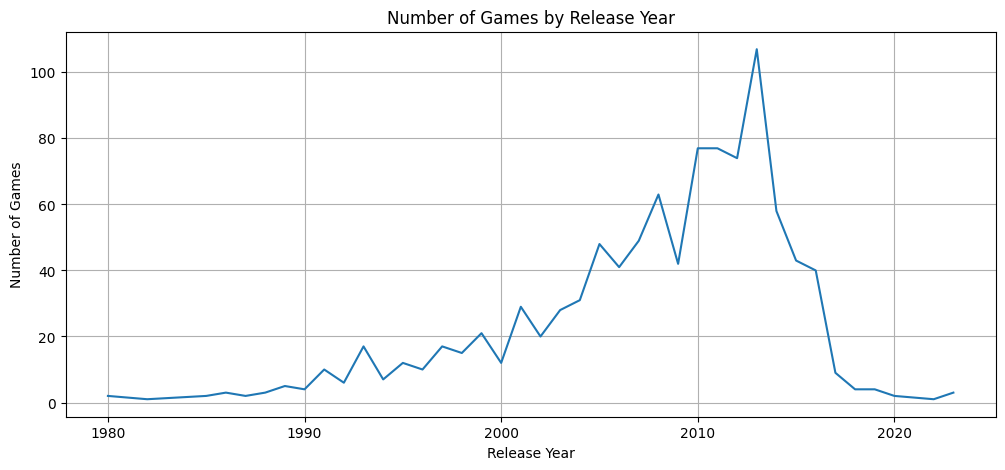

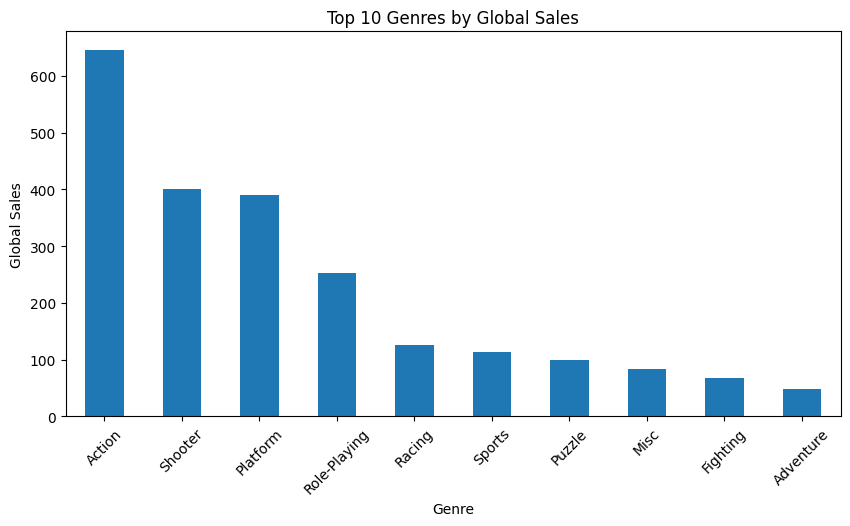

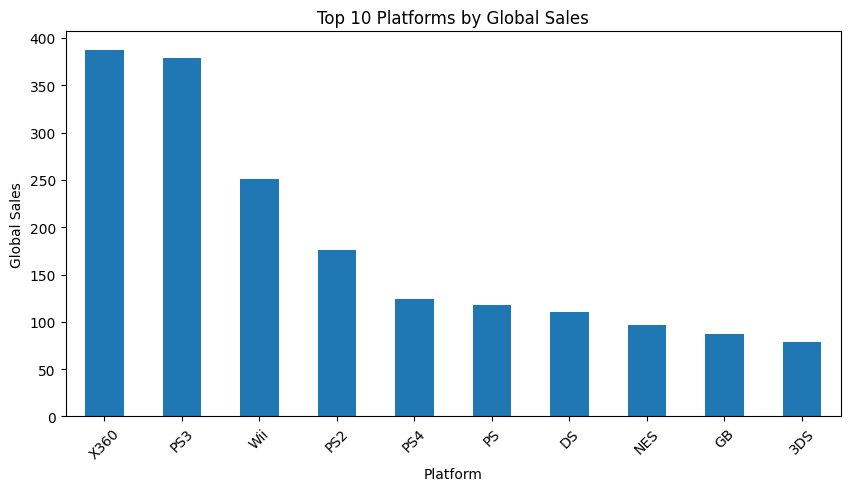

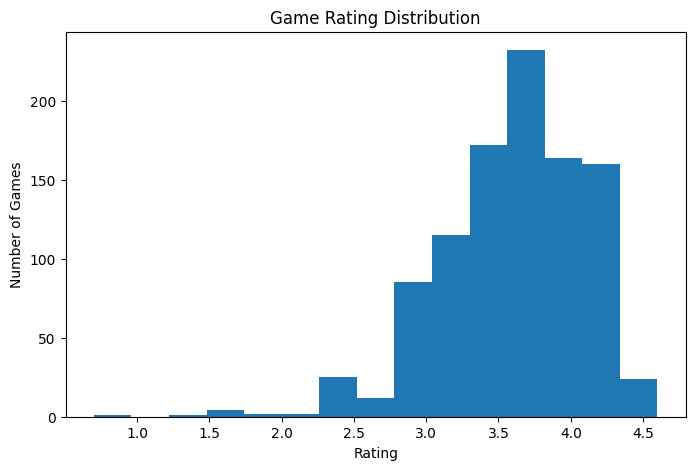

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Games by Release Year
plt.figure(figsize=(12, 5))
merged["Release Year"].value_counts().sort_index().plot()
plt.title("Number of Games by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.grid()
plt.show()

# 2. Global Sales by Genre
genre_sales = merged.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
genre_sales.plot(kind="bar")
plt.title("Top 10 Genres by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)
plt.show()

# 3. Global Sales by Platform
platform_sales = merged.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
platform_sales.plot(kind="bar")
plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)
plt.show()

# 4. Rating Distribution
plt.figure(figsize=(8, 5))
merged["Rating"].plot(kind="hist", bins=15)
plt.title("Game Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Games")
plt.show()